<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_0_Classification_Foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Predicting Credit Default: Part 1
## Logistic Regression Foundations

**Author:** Brad Sheese

---

### Learning Objectives
In this first notebook, we will establish the foundations of classification by exploring:
1. How to identify and visualize **Class Imbalance**.
2. Why **Accuracy** is often a trap in classification.
3. How to train a **Logistic Regression** model and interpret its **Coefficients**.
4. The difference between **Hard Predictions** (labels) and **Soft Predictions** (probabilities).

## Why Not Linear Regression?

Up to this point, we have used **Linear Regression** to predict continuous numbers (like House Prices). However, many real-world problems ask a binary question: *Will this customer default on their loan?* (Yes/No), *Is this email spam?* (Yes/No), *Is this tumor malignant?* (Yes/No).

If we try to force a Linear Regression line to solve these problems, we run into the "Square Peg in a Round Hole" problem. Linear lines are unbounded—they extend to infinity. But probabilities are bounded between 0 and 1. A linear model might predict a -20% chance of default or a 140% chance of being spam, both of which are mathematically nonsensical. To solve this, we use the Sigmoid (or Logistic) Function. Think of it as a "soft switch." Instead of a straight line, it creates an S-curve that squashes any input value into a range between 0 and 1.

The formula looks like this:

$$P(Y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1X_1 + \dots)}}$$

where:

TO DO: EXPLAIN VARIABLE IN FUNCTION, MORE HERE ON USE OF SIGMOID> DON"T GET INTO TOO MUCH DETAIL> WE WILL COVER SIGMOID LATER WHEN WE GO INTO LOG REG IN DETAIL>



## Problem 1: Load and Examine the Data

We will be using the **South German Credit Dataset**. Our goal is to predict whether a loan applicant is a "good" or "bad" credit risk based on features like their checking account status, credit history, and employment duration.

**Data Source:** https://archive.ics.uci.edu/dataset/522/south+german+credit



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load the Credit Card Default dataset from OpenML
from sklearn.datasets import fetch_openml

print('Loading dataset...')
data = fetch_openml(name='credit-g', version=1, as_frame=True)
df = data.frame

print(f'Dataset shape: {df.shape}')
df.head()

Loading dataset...
Dataset shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


### Examine the Dataframe
Notice the mix of numerical and categorical columns. Just like in our Regression notebooks, we will need to handle these differently.

Look closely at the `class` column. This is our **Target Variable**. It contains labels 'good' and 'bad'.

In [10]:
df['class'].head(10)

,class
0,good
1,bad
2,good
3,good
4,bad
5,good
6,good
7,good
8,good
9,bad


## Problem 2: The Accuracy Paradox and Class Imbalance

One of the most important concepts in classification is Class Distribution. In many real-world scenarios (like fraud or rare diseases), the classes are not 50/50.

If 99% of people do NOT have a rare disease, a "dumb" model that simply predicts "No Disease" for every single person will be 99% accurate. However, it is a completely useless model because it fails to catch the very thing we care about (the 1%). This is known as the Accuracy Paradox.

Let's see how imbalanced our credit dataset is.

In [12]:
# Check target variable distribution
print('Target variable distribution:')
class_counts = df['class'].value_counts(normalize=True)
print(class_counts)



Target variable distribution:
class
good    0.7
bad     0.3
Name: proportion, dtype: float64


### Discussion: Baseline Accuracy
Notice that 70% of our samples are 'Good'. This means that if we built a model that did nothing but guess 'Good' for every customer, we would achieve **70% Accuracy**.

As you move through these notebooks, always remember: If your model's accuracy isn't significantly better than the majority class percentage, your model hasn't learned anything useful.

## Problem 3: Preparing the Data for Logistic Regression

To train our model, we must perform several cleaning steps:
1. **Binary Encoding**: Convert our target ('good'/'bad') into numbers (0 and 1).
2. **One-Hot Encoding**: Convert categorical text columns (like 'employment') into multiple binary numeric columns.
3. **Stratified Split**: Ensure that our training and testing sets have the same ratio of 'good' vs 'bad' cases.
4. **Feature Scaling**: Logistic Regression uses gradient descent, which converges much faster if all features are on the same scale (e.g., mean of 0 and std of 1).

In [3]:
# 1. Convert target to binary: good = 0 (Normal), bad = 1 (Event of interest/Default)
y = (df['class'] == 'bad').astype(int)
X = df.drop(columns=['class'])

# 2. Identify and encode categorical features
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# 3. Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Original features: {X.shape[1]}')
print(f'Encoded features: {X_encoded.shape[1]}')
print(f'Training set size: {X_train.shape[0]}')

Original features: 20
Encoded features: 48
Training set size: 700


## Problem 4: Training the Logistic Regression Model

### How the Model Learns: Maximum Likelihood Estimation (MLE)
Linear regression finds the line that minimizes "Squared Error." Logistic Regression is different. It uses **Maximum Likelihood Estimation**.

The algorithm iterates through different coefficients (weights) until it finds the ones that make the labels we actually observed in the data the "most likely" outcome. If a person defaulted, the model tries to adjust its weights so that the predicted probability for that person is as close to 1.0 as possible.

### Class Weighting
Because we have an imbalanced dataset, we will use the parameter `class_weight='balanced'`. This tells the model to "pay more attention" to the minority class (the defaults). Essentially, it penalizes the model more heavily when it gets a 'Bad' credit prediction wrong than when it gets a 'Good' credit prediction wrong.

In [4]:
# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate and train the model
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Compensate for imbalance
)
model.fit(X_train_scaled, y_train)

print('Model training complete.')

Model training complete.


## Problem 5: Interpreting the Model Internals

Just like in Multiple Linear Regression, we can look at the **Coefficients** ($β$ values) to see which features are driving the model's decisions.

However, there is a catch: these coefficients are in the unit of **Log-Odds**.
- A **Positive Coefficient** means that as this feature increases, the probability of the event (Default) increases.
- A **Negative Coefficient** means that as this feature increases, the probability of Default decreases.
- A **Magnitude** (absolute value) tells you the strength of that relationship.

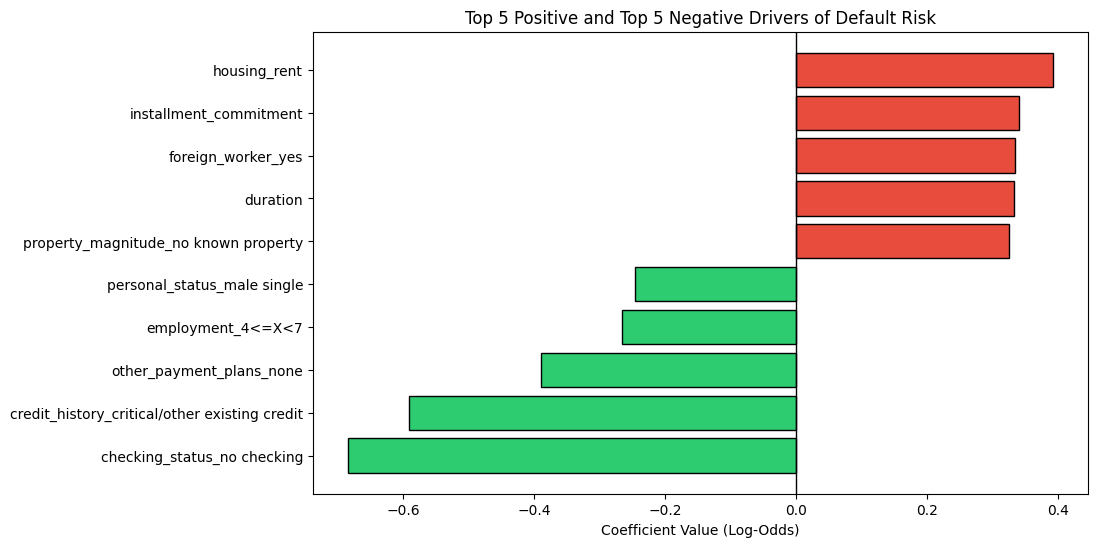

In [5]:
# Extract coefficients
coef_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

# Visualize the top drivers of default
plt.figure(figsize=(10, 6))
top_and_bottom = pd.concat([coef_df.head(5), coef_df.tail(5)])
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_and_bottom['Coefficient']]

plt.barh(top_and_bottom['Feature'], top_and_bottom['Coefficient'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Coefficient Value (Log-Odds)')
plt.title('Top 5 Positive and Top 5 Negative Drivers of Default Risk')
plt.gca().invert_yaxis()
plt.show()

### Interpret the Results
Look at the features with the largest positive coefficients (red bars). These are the factors that most strongly suggest a person will default. Conversely, the largest negative coefficients (green bars) are the strongest indicators of a "Good" credit risk.

For example, if `duration` has a large positive coefficient, it means longer loans are riskier.

## Problem 6: Probabilities and the Decision Threshold

When we ask a model to `.predict()`, it gives us a **Hard Prediction** (a 0 or a 1). But inside the model, it actually calculates a **Soft Prediction** (a probability between 0 and 1).

By default, sklearn uses a **Threshold of 0.5**:
- If $P(Default) \ge 0.5$, predict 1.
- If $P(Default) < 0.5$, predict 0.

Let's visualize how these probabilities are distributed for our test set.

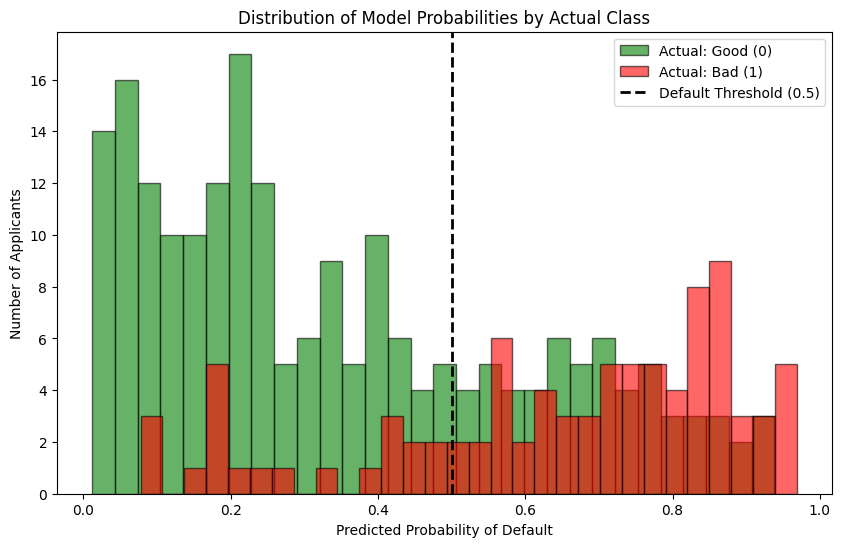

In [6]:
# Get probabilities for the positive class (Default)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot overlapping histograms by actual class
ax.hist(y_proba[y_test==0], bins=30, alpha=0.6, label='Actual: Good (0)', color='green', edgecolor='black')
ax.hist(y_proba[y_test==1], bins=30, alpha=0.6, label='Actual: Bad (1)', color='red', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Default Threshold (0.5)')

ax.set_xlabel('Predicted Probability of Default')
ax.set_ylabel('Number of Applicants')
ax.set_title('Distribution of Model Probabilities by Actual Class')
ax.legend()
plt.show()

### Discussion: Threshold Sensitivity
Look at the overlapping area in the histogram. These are applicants where the model is uncertain.

Notice that the "Actual: Bad" (red) samples are generally shifted to the right, and "Actual: Good" (green) are shifted to the left. This shows the model is working! It is assigning higher probabilities to the people who actually defaulted.

However, notice that there are many red samples to the left of the 0.5 line. These are missed cases (False Negatives). In Notebook 3, we will learn how to move that 0.5 line to better suit our business needs.

## Conclusion
In this notebook, we've moved from the world of continuous prediction to the world of classification. We've seen how the Sigmoid function allows us to predict probabilities, and how class imbalance makes accuracy a potentially deceptive metric.

We trained a model and saw that it's "internals" (coefficients) give us a rank-ordering of risk. In the next notebook, we will dive deeper into model evaluation using the confusion matrix to see exactly where our model is making mistakes.